In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../dataset/salary_data.csv")

df.head()

,Years_of_Experience,Salary
0,1.1,39000
1,1.3,41000
2,1.5,43000
3,2.0,47000
4,2.2,49000


In [3]:
df.shape

(30, 2)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Years_of_Experience  30 non-null     float64
 1   Salary               30 non-null     int64  
dtypes: float64(1), int64(1)
memory usage: 608.0 bytes


In [5]:
df.describe()

,Years_of_Experience,Salary
count,30.000000,30.000000
mean,4.956667,75166.666667
std,2.412851,23232.087402
min,1.100000,39000.000000
25%,3.050000,56500.000000
50%,4.900000,73500.000000
75%,6.725000,91500.000000
max,10.000000,125000.000000


In [6]:
df.isnull().sum()

Years_of_Experience    0
Salary                 0
dtype: int64

In [7]:
df.duplicated().sum()

0

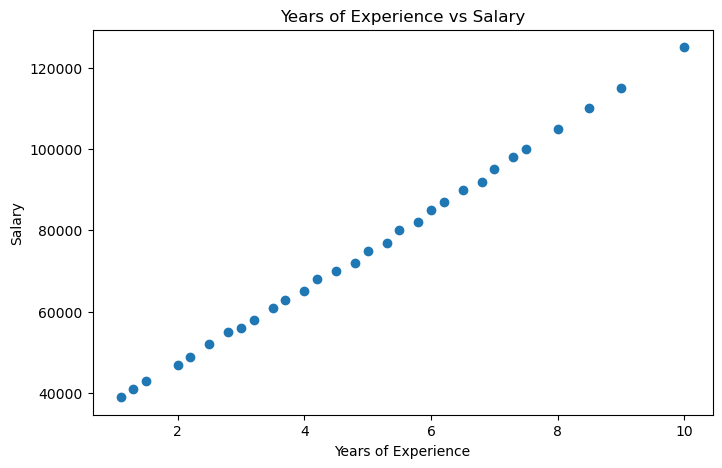

In [8]:
plt.figure(figsize=(8, 5))

plt.scatter(df["Years_of_Experience"], df["Salary"])

plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.title("Years of Experience vs Salary")

plt.show()

In [10]:
X = df[["Years_of_Experience"]]
y = df["Salary"]

print("Features (X):")
print(X.head())

print("\nTarget (y):")
print(y.head())

Features (X):
   Years_of_Experience
0                  1.1
1                  1.3
2                  1.5
3                  2.0
4                  2.2

Target (y):
0    39000
1    41000
2    43000
3    47000
4    49000
Name: Salary, dtype: int64


In [11]:
from sklearn.model_selection import train_test_split

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [13]:
print("Training feature size:", X_train.shape)
print("Testing feature size:", X_test.shape)

print("Training target size:", y_train.shape)
print("Testing target size:", y_test.shape)

Training feature size: (24, 1)
Testing feature size: (6, 1)
Training target size: (24,)
Testing target size: (6,)


In [14]:
print("Training Data:")
print(X_train)

print("\nTesting Data:")
print(X_test)

Training Data:
    Years_of_Experience
28                  9.0
24                  7.3
12                  4.2
0                   1.1
4                   2.2
16                  5.3
5                   2.5
13                  4.5
11                  4.0
22                  6.8
1                   1.3
2                   1.5
25                  7.5
3                   2.0
21                  6.5
26                  8.0
18                  5.8
29                 10.0
20                  6.2
7                   3.0
10                  3.7
14                  4.8
19                  6.0
6                   2.8

Testing Data:
    Years_of_Experience
27                  8.5
15                  5.0
23                  7.0
17                  5.5
8                   3.2
9                   3.5


In [15]:
from sklearn.linear_model import LinearRegression

In [16]:
model = LinearRegression()

In [17]:
model.fit(X_train, y_train)

LinearRegression()

In [18]:
print("Coefficient:", model.coef_[0])

Coefficient: 9600.410303168452


In [19]:
print("Intercept:", model.intercept_)

Intercept: 27598.016868019156


In [20]:
print("Linear Regression Equation:")
print(f"Salary = {model.coef_[0]:.2f} × Years_of_Experience + {model.intercept_:.2f}")

Linear Regression Equation:
Salary = 9600.41 × Years_of_Experience + 27598.02


In [21]:
y_pred = model.predict(X_test)

print("Predicted Salaries:")
print(y_pred)

Predicted Salaries:
[109201.50444495  75600.06838386  94800.8889902   80400.27353545
  58319.32983816  61199.45292911]


In [22]:
comparison = pd.DataFrame({
    "Actual Salary": y_test.values,
    "Predicted Salary": y_pred
})

print(comparison)

   Actual Salary  Predicted Salary
0         110000     109201.504445
1          75000      75600.068384
2          95000      94800.888990
3          80000      80400.273535
4          58000      58319.329838
5          61000      61199.452929


In [23]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [24]:
mae = mean_absolute_error(y_test, y_pred)

print("Mean Absolute Error (MAE):", mae)

Mean Absolute Error (MAE): 419.4552085707789


In [25]:
mse = mean_squared_error(y_test, y_pred)

print("Mean Squared Error (MSE):", mse)

Mean Squared Error (MSE): 223215.72176894266


In [26]:
rmse = np.sqrt(mse)

print("Root Mean Squared Error (RMSE):", rmse)

Root Mean Squared Error (RMSE): 472.4571110364862


In [27]:
r2 = r2_score(y_test, y_pred)

print("R² Score:", r2)

R² Score: 0.99932861843231


In [28]:
print("Model Evaluation")
print("----------------------------")
print(f"MAE  : {mae:.2f}")
print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

Model Evaluation
----------------------------
MAE  : 419.46
MSE  : 223215.72
RMSE : 472.46
R²   : 0.9993


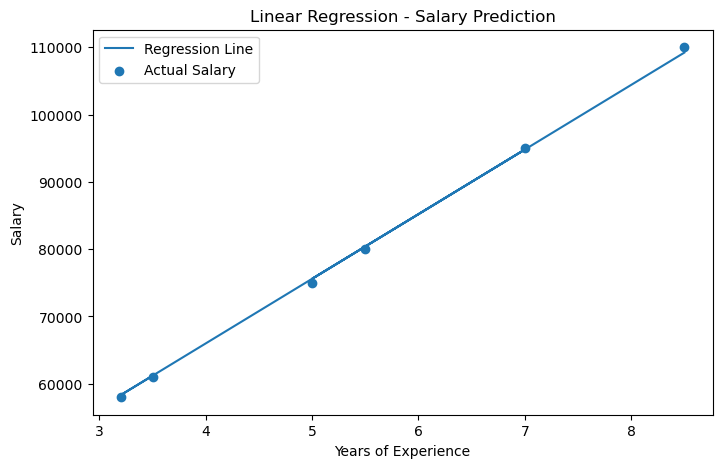

In [30]:
plt.figure(figsize=(8, 5))

plt.scatter(X_test, y_test, label="Actual Salary")

plt.plot(X_test, y_pred, label="Regression Line")

plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.title("Linear Regression - Salary Prediction")

plt.legend()

plt.savefig("../outputs/regression_plot.png", dpi=300, bbox_inches="tight")

plt.show()

In [31]:
X_test_sorted = X_test.sort_values(by="Years_of_Experience")

y_pred_sorted = model.predict(X_test_sorted)

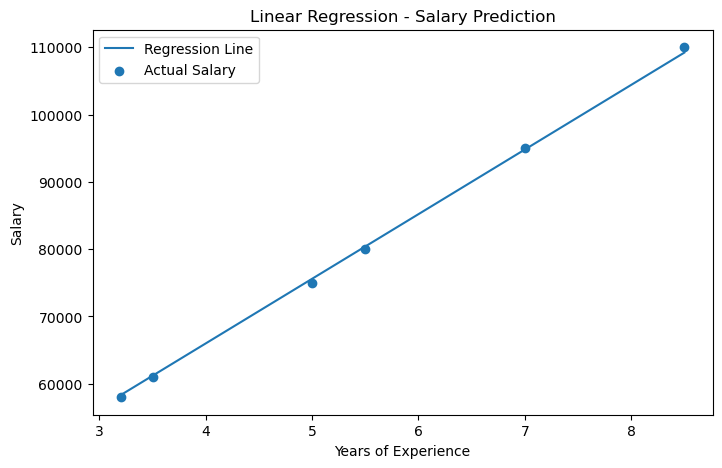

In [32]:
plt.figure(figsize=(8, 5))

plt.scatter(X_test, y_test, label="Actual Salary")

plt.plot(
    X_test_sorted,
    y_pred_sorted,
    label="Regression Line"
)

plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.title("Linear Regression - Salary Prediction")

plt.legend()

plt.savefig("../outputs/regression_plot.png", dpi=300, bbox_inches="tight")

plt.show()